# Section 1 — Environment Setup

Step 1 — Project Workspace Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

base_path = "/content/drive/MyDrive/vahan_asr_assignment"

print(os.listdir(base_path))

['audio', 'results', 'src', 'report', 'screenshots', 'ASR_Shootout.ipynb']


Step 2 — Install Required Libraries

In [3]:
!pip install -q faster-whisper
!pip install -q jiwer
!pip install -q rapidfuzz
!pip install -q librosa
!pip install -q soundfile
!pip install -q pandas
!pip install -q numpy
!pip install -q matplotlib
!pip install -q requests

In [4]:
import pandas
import numpy
import librosa
import matplotlib
import jiwer
import rapidfuzz
import requests

from faster_whisper import WhisperModel

print("All libraries installed successfully!")

All libraries installed successfully!


# Section 2 — Dataset Loading & Validation

STEP 3 — Load and Verify Audio Dataset

In [5]:
import os

audio_path = "/content/drive/MyDrive/vahan_asr_assignment/audio"

audio_files = os.listdir(audio_path)

print("Total audio files:", len(audio_files))
print("\nAudio Files:\n")

for file in audio_files:
    print(file)

Total audio files: 20

Audio Files:

sarjapur_traffic.wav
bellandur_casual.wav
silkboard_fast.wav
btmlayout_fast.wav
hsrlayout_fast.wav
yelahanka_fan.wav
banashankari_fan.wav
hebbal_fan.wav
rajajinagar_fan.wav
jayanagar_fan.wav
whitefield_quiet.wav
marathahalli_quiet.wav
electroniccity_quiet.wav
peenya_traffic.wav
indiranagar_quiet.wav
yeshwanthpur_traffic.wav
koramangala_quiet.wav
krpuram_traffic.wav
bommanahalli_traffic.wav
majestic_whisper.wav


In [6]:
import os

results_path = "/content/drive/MyDrive/vahan_asr_assignment/results"

print(os.listdir(results_path))

['ground_truth.csv', 'deepgram_results.csv', 'final_evaluation.csv', 'asr_comparison_results.csv', 'whisper_results.csv']


Step 4 — Load Ground Truth Dataset

In [7]:
import pandas as pd

gt_path = "/content/drive/MyDrive/vahan_asr_assignment/results/ground_truth.csv"

df = pd.read_csv(gt_path)

df.head()

,filename,ground_truth,locality,condition
0,sarjapur_traffic.wav,"""sarjapur road ke paas hoon""",sarjapur,traffic
1,bellandur_casual.wav,"""bellandur side mein kaam mil sakta hai kya""",bellandur,casual
2,silkboard_fast.wav,"""silk board traffic mein phas gaya""",silk board,traffic
3,btmlayout_fast.wav,"""btm layout mein stay kar raha hoon""",btm layout,fast
4,hsrlayout_fast.wav,"""hsr layout mein currently hoon""",hsr layout,fast


In [8]:
print("Total rows:", len(df))

Total rows: 20


# Section 3 — Deepgram Benchmarking

Step 5 — Configure Deepgram API

In [9]:
!pip uninstall -y deepgram-sdk
!pip install deepgram-sdk==3.2.7

Found existing installation: deepgram-sdk 3.2.7
Uninstalling deepgram-sdk-3.2.7:
  Successfully uninstalled deepgram-sdk-3.2.7
  Using cached deepgram_sdk-3.2.7-py3-none-any.whl.metadata (12 kB)
Using cached deepgram_sdk-3.2.7-py3-none-any.whl (80 kB)


In [10]:
DEEPGRAM_API_KEY = "d267ba1cde6f61bcf1e3655c7c4dd73f2bf72f35"

Step 6 — Run Initial Deepgram Transcription

In [11]:
import os
from deepgram import DeepgramClient, PrerecordedOptions

# Initialize Deepgram
deepgram = DeepgramClient(DEEPGRAM_API_KEY)

# Audio path
audio_file = "/content/drive/MyDrive/vahan_asr_assignment/audio/koramangala_quiet.wav"

# Read audio
with open(audio_file, "rb") as file:
    buffer_data = file.read()

# Better ASR options
options = PrerecordedOptions(
    model="nova-2",
    smart_format=True,
    language="hi"
)

# Transcribe
response = deepgram.listen.prerecorded.v("1").transcribe_file(
    {"buffer": buffer_data},
    options
)

# Print full response
print(response)

# Extract transcript safely
try:
    transcript = response["results"]["channels"][0]["alternatives"][0]["transcript"]
    print("\nTranscript:")
    print(transcript)
except:
    print("Transcript extraction failed")

{
    "metadata": {
        "transaction_key": "deprecated",
        "request_id": "019e1971-23e0-7173-b387-99d84b552658",
        "sha256": "94ab4dfd4fca1b2b31c90ff657fc5a2512e11886f6aeb5c0ebc6b89e5fd7a234",
        "created": "2026-05-11T23:48:26.505Z",
        "duration": 3.7335,
        "channels": 1,
        "models": [
            "a88553c1-baa3-45d7-8113-33a690ce1d6d"
        ],
        "model_info": {
            "a88553c1-baa3-45d7-8113-33a690ce1d6d": {
                "name": "2-general-nova",
                "version": "2023-09-15.32170",
                "arch": "nova-2"
            }
        }
    },
    "results": {
        "channels": [
            {
                "alternatives": [
                    {
                        "transcript": "\u0939\u093e\u0901 \u092e\u0947\u0928 \u0915\u094c\u0930\u0935\u093e \u092e\u0947\u0902 \u0930\u0916\u0924\u093e \u0939\u0942\u0901",
                        "confidence": 0.6557617,
                        "words": [
              

In [12]:
print(response)

{
    "metadata": {
        "transaction_key": "deprecated",
        "request_id": "019e1971-23e0-7173-b387-99d84b552658",
        "sha256": "94ab4dfd4fca1b2b31c90ff657fc5a2512e11886f6aeb5c0ebc6b89e5fd7a234",
        "created": "2026-05-11T23:48:26.505Z",
        "duration": 3.7335,
        "channels": 1,
        "models": [
            "a88553c1-baa3-45d7-8113-33a690ce1d6d"
        ],
        "model_info": {
            "a88553c1-baa3-45d7-8113-33a690ce1d6d": {
                "name": "2-general-nova",
                "version": "2023-09-15.32170",
                "arch": "nova-2"
            }
        }
    },
    "results": {
        "channels": [
            {
                "alternatives": [
                    {
                        "transcript": "\u0939\u093e\u0901 \u092e\u0947\u0928 \u0915\u094c\u0930\u0935\u093e \u092e\u0947\u0902 \u0930\u0916\u0924\u093e \u0939\u0942\u0901",
                        "confidence": 0.6557617,
                        "words": [
              

Step 7 — Run Deepgram Benchmark on All Audio Files

In [13]:
import os
import time
import pandas as pd
from deepgram import DeepgramClient, PrerecordedOptions

# Initialize Deepgram
deepgram = DeepgramClient(DEEPGRAM_API_KEY)

# Paths
audio_folder = "/content/drive/MyDrive/vahan_asr_assignment/audio"

# Store results
results = []

# Deepgram options
options = PrerecordedOptions(
    model="nova-2",
    smart_format=True,
    language="hi"
)

# Loop through audio files
for filename in os.listdir(audio_folder):

    if filename.endswith(".wav"):

        file_path = os.path.join(audio_folder, filename)

        # Read audio
        with open(file_path, "rb") as file:
            buffer_data = file.read()

        try:
            # Measure latency
            start_time = time.time()

            response = deepgram.listen.prerecorded.v("1").transcribe_file(
                {"buffer": buffer_data},
                options
            )

            end_time = time.time()

            latency = round(end_time - start_time, 2)

            # Extract transcript
            transcript = response["results"]["channels"][0]["alternatives"][0]["transcript"]

            # Save result
            results.append({
                "filename": filename,
                "deepgram_transcript": transcript,
                "latency_seconds": latency
            })

            print(f"Completed: {filename}")

        except Exception as e:

            results.append({
                "filename": filename,
                "deepgram_transcript": "ERROR",
                "latency_seconds": None
            })

            print(f"Error processing {filename}: {e}")

# Convert to dataframe
results_df = pd.DataFrame(results)

# Display results
results_df

Completed: sarjapur_traffic.wav
Completed: bellandur_casual.wav
Completed: silkboard_fast.wav
Completed: btmlayout_fast.wav
Completed: hsrlayout_fast.wav
Completed: yelahanka_fan.wav
Completed: banashankari_fan.wav
Completed: hebbal_fan.wav
Completed: rajajinagar_fan.wav
Completed: jayanagar_fan.wav
Completed: whitefield_quiet.wav
Completed: marathahalli_quiet.wav
Completed: electroniccity_quiet.wav
Completed: peenya_traffic.wav
Completed: indiranagar_quiet.wav
Completed: yeshwanthpur_traffic.wav
Completed: koramangala_quiet.wav
Completed: krpuram_traffic.wav
Completed: bommanahalli_traffic.wav
Completed: majestic_whisper.wav


,filename,deepgram_transcript,latency_seconds
0,sarjapur_traffic.wav,सर्ज़ा road की पास हो.,1.79
1,bellandur_casual.wav,Bellendूर side में काम मिल सकता है क्या?,2.05
2,silkboard_fast.wav,Silver traffic में फ़ंस गया.,1.84
3,btmlayout_fast.wav,B team layout में stay कर रहा हूं.,1.45
4,hsrlayout_fast.wav,अच्छा सालैयत में कहां पर है?,1.64
5,yelahanka_fan.wav,यह लड़का main मेरा घर है.,1.40
6,banashankari_fan.wav,बनासागढ़ी side से आ रहा हूं.,1.41
7,hebbal_fan.wav,के nearby रखता हूं.,1.38
8,rajajinagar_fan.wav,मैं राजा श्रीनगर area में हूं.,1.49
9,jayanagar_fan.wav,,1.39


In [14]:
print("Total processed files:", len(results_df))

Total processed files: 20


In [15]:
# Save Deepgram results CSV

output_path = "/content/drive/MyDrive/vahan_asr_assignment/results/deepgram_results.csv"

results_df.to_csv(output_path, index=False)

print("Deepgram results saved successfully!")

Deepgram results saved successfully!


In [16]:
import os

results_folder = "/content/drive/MyDrive/vahan_asr_assignment/results"

print(os.listdir(results_folder))

['ground_truth.csv', 'deepgram_results.csv', 'final_evaluation.csv', 'asr_comparison_results.csv', 'whisper_results.csv']


# Section 4 — Evaluation Metrics & Failure Analysis

Step 8 — Create Evaluation Dataset

In [17]:
import pandas as pd

# Load ground truth
gt_df = pd.read_csv(
    "/content/drive/MyDrive/vahan_asr_assignment/results/ground_truth.csv"
)

# Load Deepgram results
deepgram_df = pd.read_csv(
    "/content/drive/MyDrive/vahan_asr_assignment/results/deepgram_results.csv"
)

print("Ground Truth Rows:", len(gt_df))
print("Deepgram Rows:", len(deepgram_df))

Ground Truth Rows: 20
Deepgram Rows: 20


In [18]:
# Merge datasets using filename

merged_df = pd.merge(
    gt_df,
    deepgram_df,
    on="filename"
)

# Display merged dataset
merged_df.head()

,filename,ground_truth,locality,condition,deepgram_transcript,latency_seconds
0,sarjapur_traffic.wav,"""sarjapur road ke paas hoon""",sarjapur,traffic,सर्ज़ा road की पास हो.,1.79
1,bellandur_casual.wav,"""bellandur side mein kaam mil sakta hai kya""",bellandur,casual,Bellendूर side में काम मिल सकता है क्या?,2.05
2,silkboard_fast.wav,"""silk board traffic mein phas gaya""",silk board,traffic,Silver traffic में फ़ंस गया.,1.84
3,btmlayout_fast.wav,"""btm layout mein stay kar raha hoon""",btm layout,fast,B team layout में stay कर रहा हूं.,1.45
4,hsrlayout_fast.wav,"""hsr layout mein currently hoon""",hsr layout,fast,अच्छा सालैयत में कहां पर है?,1.64


In [19]:
print("Merged rows:", len(merged_df))

Merged rows: 20


Step 9 — Compute ASR Evaluation Metrics

In [20]:
from jiwer import wer, cer
from rapidfuzz import fuzz

In [21]:
# Calculate WER and CER for each row

merged_df["WER"] = merged_df.apply(
    lambda row: wer(
        str(row["ground_truth"]).lower(),
        str(row["deepgram_transcript"]).lower()
    ),
    axis=1
)

merged_df["CER"] = merged_df.apply(
    lambda row: cer(
        str(row["ground_truth"]).lower(),
        str(row["deepgram_transcript"]).lower()
    ),
    axis=1
)

# Display results
merged_df[[
    "filename",
    "WER",
    "CER"
]].head()

,filename,WER,CER
0,sarjapur_traffic.wav,0.800000,0.714286
1,bellandur_casual.wav,0.875000,0.636364
2,silkboard_fast.wav,0.833333,0.571429
3,btmlayout_fast.wav,0.857143,0.555556
4,hsrlayout_fast.wav,1.200000,0.906250


In [22]:
# Simple entity match

merged_df["entity_detected"] = merged_df.apply(
    lambda row: (
        str(row["locality"]).lower()
        in str(row["deepgram_transcript"]).lower()
    ),
    axis=1
)

# Display entity detection results
merged_df[[
    "filename",
    "locality",
    "deepgram_transcript",
    "entity_detected"
]].head(10)

,filename,locality,deepgram_transcript,entity_detected
0,sarjapur_traffic.wav,sarjapur,सर्ज़ा road की पास हो.,False
1,bellandur_casual.wav,bellandur,Bellendूर side में काम मिल सकता है क्या?,False
2,silkboard_fast.wav,silk board,Silver traffic में फ़ंस गया.,False
3,btmlayout_fast.wav,btm layout,B team layout में stay कर रहा हूं.,False
4,hsrlayout_fast.wav,hsr layout,अच्छा सालैयत में कहां पर है?,False
5,yelahanka_fan.wav,yelahanka,यह लड़का main मेरा घर है.,False
6,banashankari_fan.wav,banashankari,बनासागढ़ी side से आ रहा हूं.,False
7,hebbal_fan.wav,hebbal,के nearby रखता हूं.,False
8,rajajinagar_fan.wav,rajajinagar,मैं राजा श्रीनगर area में हूं.,False
9,jayanagar_fan.wav,jayanagar,NaN,False


In [23]:
average_wer = merged_df["WER"].mean()
average_cer = merged_df["CER"].mean()
entity_accuracy = merged_df["entity_detected"].mean()

print("Average WER:", round(average_wer, 2))
print("Average CER:", round(average_cer, 2))
print("Entity Accuracy:", round(entity_accuracy * 100, 2), "%")

Average WER: 0.97
Average CER: 0.74
Entity Accuracy: 0.0 %


Step 10 — Perform Failure Analysis

In [24]:
merged_df[[
    "filename",
    "condition",
    "ground_truth",
    "deepgram_transcript",
    "WER",
    "CER"
]]

,filename,condition,ground_truth,deepgram_transcript,WER,CER
0,sarjapur_traffic.wav,traffic,"""sarjapur road ke paas hoon""",सर्ज़ा road की पास हो.,0.800000,0.714286
1,bellandur_casual.wav,casual,"""bellandur side mein kaam mil sakta hai kya""",Bellendूर side में काम मिल सकता है क्या?,0.875000,0.636364
2,silkboard_fast.wav,traffic,"""silk board traffic mein phas gaya""",Silver traffic में फ़ंस गया.,0.833333,0.571429
3,btmlayout_fast.wav,fast,"""btm layout mein stay kar raha hoon""",B team layout में stay कर रहा हूं.,0.857143,0.555556
4,hsrlayout_fast.wav,fast,"""hsr layout mein currently hoon""",अच्छा सालैयत में कहां पर है?,1.200000,0.906250
5,yelahanka_fan.wav,fan,"""yelahanka mein mera ghar hai""",यह लड़का main मेरा घर है.,1.200000,0.766667
6,banashankari_fan.wav,fan,"""banashankari side se aa raha hoon""",बनासागढ़ी side से आ रहा हूं.,0.833333,0.742857
7,hebbal_fan.wav,fan,"""hebbal ke nearby rehta hoon""",के nearby रखता हूं.,0.800000,0.689655
8,rajajinagar_fan.wav,fan,"""main rajajinagar area mein hoon""",मैं राजा श्रीनगर area में हूं.,1.000000,0.787879
9,jayanagar_fan.wav,fan,"""jayanagar se office jaata hoon""",NaN,1.000000,0.906250


In [25]:
# Sort by highest WER

worst_cases = merged_df.sort_values(
    by="WER",
    ascending=False
)

# Show worst predictions
worst_cases[[
    "filename",
    "condition",
    "ground_truth",
    "deepgram_transcript",
    "WER"
]].head(10)

,filename,condition,ground_truth,deepgram_transcript,WER
19,majestic_whisper.wav,whisper,"""majestic ke paas utarna hai""",जलंधर side में काम मिल सकता है क्या?,1.60
15,yeshwanthpur_traffic.wav,traffic,"""yeshwanthpur se bus pakadunga""",ईश्वरपुर से बस ताकत होगा.,1.25
5,yelahanka_fan.wav,fan,"""yelahanka mein mera ghar hai""",यह लड़का main मेरा घर है.,1.20
4,hsrlayout_fast.wav,fast,"""hsr layout mein currently hoon""",अच्छा सालैयत में कहां पर है?,1.20
18,bommanahalli_traffic.wav,traffic,"""bommanahalli mein interview hai""",बोमनली में interviews है.,1.00
14,indiranagar_quiet.wav,quiet,"""indiranagar side se bol raha hoon""",शुबरा नगर side से बोल रहा हूं.,1.00
9,jayanagar_fan.wav,fan,"""jayanagar se office jaata hoon""",NaN,1.00
8,rajajinagar_fan.wav,fan,"""main rajajinagar area mein hoon""",मैं राजा श्रीनगर area में हूं.,1.00
10,whitefield_quiet.wav,quiet,"""mera ghar whitefield ke paas hai""",मेरा घर weightfield की पास है.,1.00
16,koramangala_quiet.wav,quiet,"""haan main koramangala mein rehta hoon""",हाँ मेन कौरवा में रखता हूँ,1.00


In [26]:
condition_analysis = merged_df.groupby("condition")[[
    "WER",
    "CER",
    "latency_seconds"
]].mean()

condition_analysis

,WER,CER,latency_seconds
condition,,,
casual,0.875000,0.636364,2.050000
fan,0.966667,0.778662,1.414000
fast,1.028571,0.730903,1.545000
quiet,0.904762,0.748555,1.504000
traffic,0.926389,0.657969,1.911667
whisper,1.600000,1.068966,1.430000


In [27]:
final_output = "/content/drive/MyDrive/vahan_asr_assignment/results/final_evaluation.csv"

merged_df.to_csv(final_output, index=False)

print("Final evaluation dataset saved successfully!")

Final evaluation dataset saved successfully!


# Section 5 — Whisper Benchmarking

Step 11 — Configure Faster-Whisper

In [28]:
!pip install -q faster-whisper

In [29]:
from faster_whisper import WhisperModel

# Load Whisper model using CPU
model = WhisperModel(
    "small",
    device="cpu",
    compute_type="int8"
)

print("Whisper model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Whisper model loaded successfully!


In [30]:
audio_path = "/content/drive/MyDrive/vahan_asr_assignment/audio/koramangala_quiet.wav"

segments, info = model.transcribe(
    audio_path,
    beam_size=5
)

# Combine transcript
transcript = ""

for segment in segments:
    transcript += segment.text + " "

print("Whisper Transcript:")
print(transcript)

Whisper Transcript:
 हा, में कोरमगला में रखता हूँ 


Step 12 — Run Whisper Benchmark on All Audio Files

In [31]:
import os
import time
import pandas as pd

# Audio folder
audio_folder = "/content/drive/MyDrive/vahan_asr_assignment/audio"

# Store results
whisper_results = []

# Loop through files
for filename in os.listdir(audio_folder):

    if filename.endswith(".wav"):

        file_path = os.path.join(audio_folder, filename)

        try:
            # Measure latency
            start_time = time.time()

            segments, info = model.transcribe(
                file_path,
                beam_size=5
            )

            # Combine transcript
            transcript = ""

            for segment in segments:
                transcript += segment.text + " "

            end_time = time.time()

            latency = round(end_time - start_time, 2)

            # Save result
            whisper_results.append({
                "filename": filename,
                "whisper_transcript": transcript.strip(),
                "whisper_latency": latency
            })

            print(f"Completed: {filename}")

        except Exception as e:

            whisper_results.append({
                "filename": filename,
                "whisper_transcript": "ERROR",
                "whisper_latency": None
            })

            print(f"Error processing {filename}: {e}")

# Convert to dataframe
whisper_df = pd.DataFrame(whisper_results)

# Display results
whisper_df

Completed: sarjapur_traffic.wav
Completed: bellandur_casual.wav
Completed: silkboard_fast.wav
Completed: btmlayout_fast.wav
Completed: hsrlayout_fast.wav
Completed: yelahanka_fan.wav
Completed: banashankari_fan.wav
Completed: hebbal_fan.wav
Completed: rajajinagar_fan.wav
Completed: jayanagar_fan.wav
Completed: whitefield_quiet.wav
Completed: marathahalli_quiet.wav
Completed: electroniccity_quiet.wav
Completed: peenya_traffic.wav
Completed: indiranagar_quiet.wav
Completed: yeshwanthpur_traffic.wav
Completed: koramangala_quiet.wav
Completed: krpuram_traffic.wav
Completed: bommanahalli_traffic.wav
Completed: majestic_whisper.wav


,filename,whisper_transcript,whisper_latency
0,sarjapur_traffic.wav,सर्जा प्रा रोड की पास हो,15.18
1,bellandur_casual.wav,بلندور سائد میں کام مل سکتا ہے کیا؟,14.82
2,silkboard_fast.wav,सिल्बो त्राफिक में पस गया,15.30
3,btmlayout_fast.wav,बी तीम लेवट में स्थे कर रवा हूँ,16.09
4,hsrlayout_fast.wav,,120.62
5,yelahanka_fan.wav,ये लांका में मेरा गेर है,15.26
6,banashankari_fan.wav,Buon appetito!,13.68
7,hebbal_fan.wav,इबल के निर्भे रेक्ता हूँ,15.14
8,rajajinagar_fan.wav,मेर अचा सी नगरी लिए में हुं,15.56
9,jayanagar_fan.wav,,14.71


In [32]:
# Save Whisper results

whisper_output = "/content/drive/MyDrive/vahan_asr_assignment/results/whisper_results.csv"

whisper_df.to_csv(whisper_output, index=False)

print("Whisper results saved successfully!")

Whisper results saved successfully!


In [33]:
import os

results_folder = "/content/drive/MyDrive/vahan_asr_assignment/results"

print(os.listdir(results_folder))

['ground_truth.csv', 'deepgram_results.csv', 'final_evaluation.csv', 'asr_comparison_results.csv', 'whisper_results.csv']


In [34]:
print("Total Whisper files processed:", len(whisper_df))

Total Whisper files processed: 20


# Section 6 — Model Comparison Analysis

Step 13 — Compare Deepgram and Whisper Performance

In [35]:
# Merge Whisper results into main dataframe

comparison_df = pd.merge(
    merged_df,
    whisper_df,
    on="filename"
)

# Display dataframe
comparison_df.head()

,filename,ground_truth,locality,condition,deepgram_transcript,latency_seconds,WER,CER,entity_detected,whisper_transcript,whisper_latency
0,sarjapur_traffic.wav,"""sarjapur road ke paas hoon""",sarjapur,traffic,सर्ज़ा road की पास हो.,1.79,0.800000,0.714286,False,सर्जा प्रा रोड की पास हो,15.18
1,bellandur_casual.wav,"""bellandur side mein kaam mil sakta hai kya""",bellandur,casual,Bellendूर side में काम मिल सकता है क्या?,2.05,0.875000,0.636364,False,بلندور سائد میں کام مل سکتا ہے کیا؟,14.82
2,silkboard_fast.wav,"""silk board traffic mein phas gaya""",silk board,traffic,Silver traffic में फ़ंस गया.,1.84,0.833333,0.571429,False,सिल्बो त्राफिक में पस गया,15.30
3,btmlayout_fast.wav,"""btm layout mein stay kar raha hoon""",btm layout,fast,B team layout में stay कर रहा हूं.,1.45,0.857143,0.555556,False,बी तीम लेवट में स्थे कर रवा हूँ,16.09
4,hsrlayout_fast.wav,"""hsr layout mein currently hoon""",hsr layout,fast,अच्छा सालैयत में कहां पर है?,1.64,1.200000,0.906250,False,,120.62


In [36]:
from jiwer import wer, cer

# Whisper WER
comparison_df["whisper_WER"] = comparison_df.apply(
    lambda row: wer(
        str(row["ground_truth"]).lower(),
        str(row["whisper_transcript"]).lower()
    ),
    axis=1
)

# Whisper CER
comparison_df["whisper_CER"] = comparison_df.apply(
    lambda row: cer(
        str(row["ground_truth"]).lower(),
        str(row["whisper_transcript"]).lower()
    ),
    axis=1
)

# Display results
comparison_df[[
    "filename",
    "whisper_WER",
    "whisper_CER"
]].head()

,filename,whisper_WER,whisper_CER
0,sarjapur_traffic.wav,1.200000,0.892857
1,bellandur_casual.wav,1.000000,0.840909
2,silkboard_fast.wav,1.000000,0.885714
3,btmlayout_fast.wav,1.142857,0.861111
4,hsrlayout_fast.wav,1.000000,1.000000


In [37]:
comparison_df["whisper_entity_detected"] = comparison_df.apply(
    lambda row: (
        str(row["locality"]).lower()
        in str(row["whisper_transcript"]).lower()
    ),
    axis=1
)

comparison_df[[
    "filename",
    "locality",
    "whisper_transcript",
    "whisper_entity_detected"
]].head(10)

,filename,locality,whisper_transcript,whisper_entity_detected
0,sarjapur_traffic.wav,sarjapur,सर्जा प्रा रोड की पास हो,False
1,bellandur_casual.wav,bellandur,بلندور سائد میں کام مل سکتا ہے کیا؟,False
2,silkboard_fast.wav,silk board,सिल्बो त्राफिक में पस गया,False
3,btmlayout_fast.wav,btm layout,बी तीम लेवट में स्थे कर रवा हूँ,False
4,hsrlayout_fast.wav,hsr layout,,False
5,yelahanka_fan.wav,yelahanka,ये लांका में मेरा गेर है,False
6,banashankari_fan.wav,banashankari,Buon appetito!,False
7,hebbal_fan.wav,hebbal,इबल के निर्भे रेक्ता हूँ,False
8,rajajinagar_fan.wav,rajajinagar,मेर अचा सी नगरी लिए में हुं,False
9,jayanagar_fan.wav,jayanagar,,False


In [38]:
# Deepgram metrics
deepgram_wer = comparison_df["WER"].mean()
deepgram_cer = comparison_df["CER"].mean()
deepgram_entity = comparison_df["entity_detected"].mean()
deepgram_latency = comparison_df["latency_seconds"].mean()

# Whisper metrics
whisper_wer = comparison_df["whisper_WER"].mean()
whisper_cer = comparison_df["whisper_CER"].mean()
whisper_entity = comparison_df["whisper_entity_detected"].mean()
whisper_latency = comparison_df["whisper_latency"].mean()

# Print comparison
print("===== Deepgram =====")
print("WER:", round(deepgram_wer, 2))
print("CER:", round(deepgram_cer, 2))
print("Entity Accuracy:", round(deepgram_entity * 100, 2), "%")
print("Latency:", round(deepgram_latency, 2), "sec")

print("\n===== Whisper =====")
print("WER:", round(whisper_wer, 2))
print("CER:", round(whisper_cer, 2))
print("Entity Accuracy:", round(whisper_entity * 100, 2), "%")
print("Latency:", round(whisper_latency, 2), "sec")

===== Deepgram =====
WER: 0.97
CER: 0.74
Entity Accuracy: 0.0 %
Latency: 1.63 sec

===== Whisper =====
WER: 1.12
CER: 0.91
Entity Accuracy: 0.0 %
Latency: 21.66 sec


In [39]:
comparison_output = "/content/drive/MyDrive/vahan_asr_assignment/results/asr_comparison_results.csv"

comparison_df.to_csv(comparison_output, index=False)

print("ASR comparison results saved successfully!")

ASR comparison results saved successfully!


# Section 7 — Visualization & Insights

Step 14 — Create Benchmark Visualizations

In [40]:
summary_df = pd.DataFrame({
    "Model": ["Deepgram", "Whisper"],
    "WER": [deepgram_wer, whisper_wer],
    "CER": [deepgram_cer, whisper_cer],
    "Entity_Accuracy": [
        deepgram_entity * 100,
        whisper_entity * 100
    ],
    "Latency": [
        deepgram_latency,
        whisper_latency
    ]
})

summary_df

,Model,WER,CER,Entity_Accuracy,Latency
0,Deepgram,0.972381,0.737552,0.0,1.6315
1,Whisper,1.117143,0.906871,0.0,21.6590


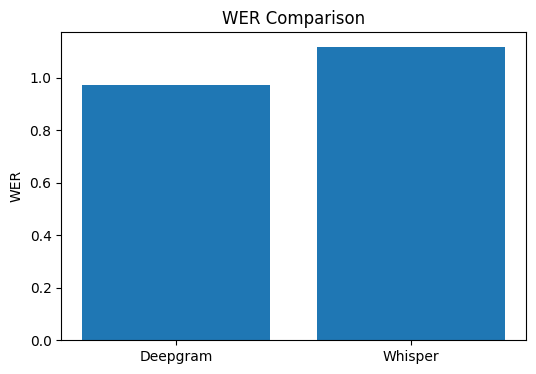

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    summary_df["Model"],
    summary_df["WER"]
)

plt.title("WER Comparison")
plt.ylabel("WER")

plt.show()

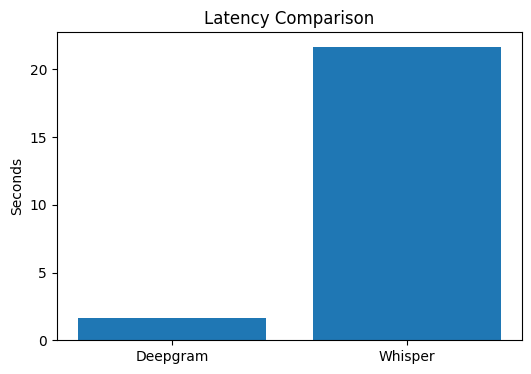

In [42]:
plt.figure(figsize=(6,4))

plt.bar(
    summary_df["Model"],
    summary_df["Latency"]
)

plt.title("Latency Comparison")
plt.ylabel("Seconds")

plt.show()

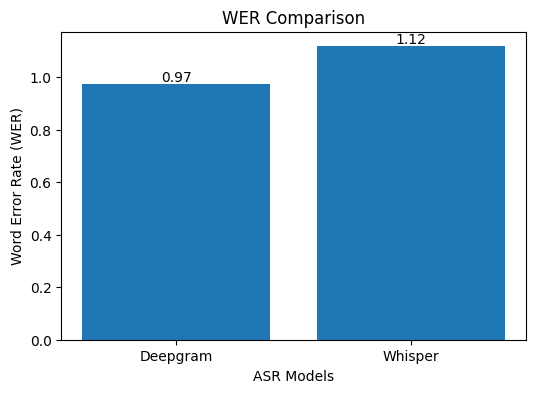

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    summary_df["Model"],
    summary_df["WER"]
)

# Title
plt.title("WER Comparison")

# Axis labels
plt.xlabel("ASR Models")
plt.ylabel("Word Error Rate (WER)")

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.show()

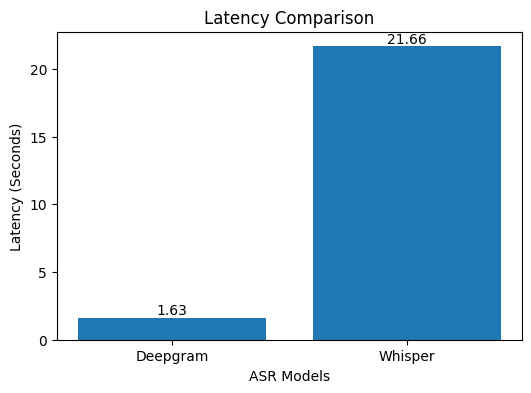

In [44]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    summary_df["Model"],
    summary_df["Latency"]
)

# Title
plt.title("Latency Comparison")

# Axis labels
plt.xlabel("ASR Models")
plt.ylabel("Latency (Seconds)")

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.show()